In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import fftconvolve, spectrogram
from tqdm import tqdm

# --- Path & Custom Library Setup ---
sys.path.append('../../')
from Code.scripts.adaptive_notch_filter_functions import (
    JammerSignalProcessor,
    GoldCodeGenerator
)

# -------------------------------------------------------------------------
# SIMULATION SETUP
# -------------------------------------------------------------------------
# Timing and Frequency Configuration
f_samplerate    = 2.56e6
sweep_time      = 10e-3
main_lobe_width = 1.253e6
jammer_freqs    = [-main_lobe_width, main_lobe_width]
chirp_rate      = (jammer_freqs[1] - jammer_freqs[0]) / sweep_time
jitter_std      = 1e3
jammer_amp_dB   = 80
taper_ratio     = 0.1

# Vectors
N_samples = int(1.0 * f_samplerate)
t_vec     = np.arange(N_samples) / f_samplerate

# Generate the Signal of Interest (GNSS with PRN = 27)
gen = GoldCodeGenerator(PRN=27, samp_rate=f_samplerate, vectorLength=N_samples)
signal_of_interest = gen.process()  

# Generate LFM Jamming signal (Chirp Jammer)
jammer = GoldCodeGenerator.create_linear_FM_signal(
    jammer_freqs, 
    t_vec, 
    f_samplerate, 
    amplitude   = 10**(jammer_amp_dB/20), 
    chirp_rate  = chirp_rate, 
    jitter_std  = jitter_std, 
    taper_ratio = taper_ratio
)

# Observe the combined signal
signal = signal_of_interest + jammer

print(f"Jammer parameters: \nChirp Rate: {chirp_rate:.2f} Hz/s\nFrequency Range: {jammer_freqs[0]:.2f} to {jammer_freqs[1]:.2f} Hz")

# -------------------------------------------------------------------------
# 1. CHUNKING AND PARAMETERIZATION
# -------------------------------------------------------------------------
acquisition_chunk_size = int(0.5 * f_samplerate) 
start_idx = 264532 # Selected window offset
taper_sec = 0.0002 # 200µs Tukey windowing

# Extract chunk for analysis
acquisition_chunk = signal[start_idx : start_idx + acquisition_chunk_size]

# Parameterization (Includes Sub-Bin Peak Detection & Drift Refinement)
params = JammerSignalProcessor.estimate_jammer_physics(
    acquisition_chunk, 
    f_samplerate, 
    start_idx, 
    taper_sec, 
    spectrogram_nperseg=1024, 
    spectrogram_overlap=819
)

# -------------------------------------------------------------------------
# 2. DESIGNING AN ADAPTIVE NOTCH FILTER
# -------------------------------------------------------------------------
N_taps, notch_width, transition_width_Hz = JammerSignalProcessor.calculate_filter_parameters(
    params.chirp_rate, 
    f_samplerate,
    params.bandwidth,
    notch_width_percentage=0.2,
    transition_width_multiplier=0.1,
    max_phase=1.17
)

attenuation_dB = 81

h = JammerSignalProcessor.dc_firwin_filter(N_taps, f_samplerate, notch_width, attenuation_dB, transition_width_Hz)
group_delay = (N_taps - 1) // 2

print(f"Filter Ready: {N_taps} Taps | Group Delay: {group_delay} samples")

# -------------------------------------------------------------------------
# 3. PROCESSING: Continuous Overlap-Add (OLA) Loop
# -------------------------------------------------------------------------

chunk_size = int(0.02 * f_samplerate) # 20ms processing blocks
tail_length   = N_taps - 1
output_signal = np.zeros(N_samples + tail_length, dtype=complex)


for i_start in tqdm(range(0, N_samples, chunk_size)):
    i_end = min(i_start + chunk_size, N_samples)
    current_length = i_end - i_start
    if current_length == 0: break
    
    full_convolution_length = current_length + tail_length
    signal_chunk  = signal[i_start : i_end]

    # --- Downconversion LO ---
    t_local = (i_start + np.arange(current_length)) / f_samplerate
    LO_down, _ = JammerSignalProcessor.LO_calculator(   
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_local, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # --- Upconversion LO with Group-Delay Compensation ---
    t_up = (i_start - group_delay + np.arange(full_convolution_length)) / f_samplerate
    _, LO_up = JammerSignalProcessor.LO_calculator(
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_up, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # Core DSP Pipeline
    signal_downconverted = signal_chunk * LO_down

    # Filter (Expanding to Full length to capture the ringing tail)
    signal_filtered = fftconvolve(signal_downconverted, h, mode = "full")
    processed_block = signal_filtered * LO_up

    # Overlap-Add: Tail from current chunk sums with the start of the next
    output_signal[i_start : i_start + full_convolution_length] += processed_block
    

# -------------------------------------------------------------------------
# 5. VALIDATION: Final Signal Reconstruction
# -------------------------------------------------------------------------
# Align recovered signal by removing the filter's physical delay
recovered_signal = output_signal[group_delay : N_samples + group_delay]

# Discard edges to avoid filter transient artifacts
safety_margin = N_taps * 2
reference_clean = signal_of_interest[safety_margin : N_samples - safety_margin]
reference_filtered  = recovered_signal[safety_margin : N_samples - safety_margin]

max_correlation = JammerSignalProcessor.analyze_correlation(reference_clean, reference_filtered)

print("\n" + "=" * 50)
print(f"Final Global Correlation: {max_correlation:.4f}")
print("=" * 50)

Jammer parameters: 
Chirp Rate: 250600000.00 Hz/s
Frequency Range: -1253000.00 to 1253000.00 Hz
Residual Error Detected: Chirp Drift = 252.09 kHz/s
Freq Offset = 32.39 kHz
R² of Fit = 0.8992
Filter Ready: 201 Taps | Group Delay: 100 samples


100%|██████████| 50/50 [00:00<00:00, 67.78it/s]



Final Global Correlation: 0.9360


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import fftconvolve, spectrogram
from tqdm import tqdm

# --- Path & Custom Library Setup ---
sys.path.append('../../')
from Code.scripts.adaptive_notch_filter_functions import (
    JammerSignalProcessor,
    GoldCodeGenerator
)

# -------------------------------------------------------------------------
# SIMULATION SETUP
# -------------------------------------------------------------------------
# Timing and Frequency Configuration
f_samplerate    = 2.56e6
sweep_time      = 10e-3
main_lobe_width = 1.253e6
jammer_freqs    = [-main_lobe_width, main_lobe_width]
chirp_rate      = (jammer_freqs[1] - jammer_freqs[0]) / sweep_time
jitter_std      = 1e3
jammer_amp_dB   = 80
taper_ratio     = 0.1

# Vectors
N_samples = int(20.0 * f_samplerate)
t_vec     = np.arange(N_samples) / f_samplerate

# Generate the Signal of Interest (GNSS with PRN = 27)
gen = GoldCodeGenerator(PRN=27, samp_rate=f_samplerate, vectorLength=N_samples)
signal_of_interest = gen.process()  

# Generate LFM Jamming signal (Chirp Jammer)
jammer = GoldCodeGenerator.create_linear_FM_signal(
    jammer_freqs, 
    t_vec, 
    f_samplerate, 
    amplitude=10**(jammer_amp_dB/20), 
    chirp_rate  = chirp_rate, 
    jitter_std  = jitter_std, 
    taper_ratio = taper_ratio
)

# Observe the combined signal
signal = signal_of_interest + jammer

print(f"Jammer parameters: \nChirp Rate: {chirp_rate:.2f} Hz/s\nFrequency Range: {jammer_freqs[0]:.2f} to {jammer_freqs[1]:.2f} Hz")

# -------------------------------------------------------------------------
# 1. CHUNKING AND PARAMETERIZATION
# -------------------------------------------------------------------------
acquisition_chunk_size = int(0.5 * f_samplerate) 
start_idx = 26453 # Selected window offset
taper_sec = 0.0002 # 200µs Tukey windowing

# Extract chunk for analysis
acquisition_chunk = signal[start_idx : start_idx + acquisition_chunk_size]

# Parameterization (Includes Sub-Bin Peak Detection & Drift Refinement)
params = JammerSignalProcessor.estimate_jammer_physics(
    acquisition_chunk, 
    f_samplerate, 
    start_idx, 
    taper_sec, 
    spectrogram_nperseg=1024, 
    spectrogram_overlap=819
)

# -------------------------------------------------------------------------
# 2. DESIGNING AN ADAPTIVE NOTCH FILTER
# -------------------------------------------------------------------------
N_taps, notch_width, transition_width_Hz = JammerSignalProcessor.calculate_filter_parameters(
    params.chirp_rate, 
    f_samplerate,
    params.bandwidth,
    notch_width_percentage=0.2,
    transition_width_multiplier=0.1,
    max_phase=1.17
)

attenuation_dB = 81

h = JammerSignalProcessor.dc_firwin_filter(N_taps, f_samplerate, notch_width, attenuation_dB, transition_width_Hz)
group_delay = (N_taps - 1) // 2

print(f"Filter Ready: {N_taps} Taps | Group Delay: {group_delay} samples")

# -------------------------------------------------------------------------
# 3. PROCESSING: Continuous Overlap-Add (OLA) Loop
# -------------------------------------------------------------------------

chunk_size = int(0.02 * f_samplerate) # 20ms processing blocks
tail_length   = N_taps - 1
output_signal = np.zeros(N_samples + tail_length, dtype=complex)

# Telemetry
diag_downconverted = np.zeros(N_samples, dtype=complex)
rolling_corr, rolling_snr, time_stamps = [], [], []


for i_start in tqdm(range(0, N_samples, chunk_size)):
    i_end = min(i_start + chunk_size, N_samples)
    current_length = i_end - i_start
    if current_length == 0: break
    
    full_convolution_length = current_length + tail_length
    signal_chunk  = signal[i_start : i_end]

    # --- Downconversion LO ---
    t_local = (i_start + np.arange(current_length)) / f_samplerate
    LO_down, _ = JammerSignalProcessor.LO_calculator(   
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_local, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # --- Upconversion LO with Group-Delay Compensation ---
    t_up = (i_start - group_delay + np.arange(full_convolution_length)) / f_samplerate
    _, LO_up = JammerSignalProcessor.LO_calculator(
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_up, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # Core DSP Pipeline
    signal_downconverted = signal_chunk * LO_down

    # Filter (Expanding to Full length to capture the ringing tail)
    signal_filtered = fftconvolve(signal_downconverted, h, mode = "full")
    processed_block = signal_filtered * LO_up

    # Overlap-Add: Tail from current chunk sums with the start of the next
    output_signal[i_start : i_start + full_convolution_length] += processed_block
    
    # Diagnostics
    diag_downconverted[i_start:i_end] = signal_downconverted # Capture for spectrogram

    # In-Loop Telemetry (Verify coherence as we go)
    if i_start > 0:
        t_histogram_start = i_start - chunk_size
        clean_slice       = signal_of_interest[t_histogram_start : i_start]
        recovered_slice   = output_signal[t_histogram_start + group_delay : i_start + group_delay]
        
        correlation = JammerSignalProcessor.analyze_correlation(clean_slice, recovered_slice)
        snr  = 10 * np.log10(np.var(clean_slice) / np.var(recovered_slice - clean_slice))
        
        rolling_corr.append(correlation)
        rolling_snr.append(snr)
        time_stamps.append(t_histogram_start / f_samplerate)

# -------------------------------------------------------------------------
# 5. VALIDATION: Final Signal Reconstruction
# -------------------------------------------------------------------------
# Align recovered signal by removing the filter's physical delay
recovered_signal = output_signal[group_delay : N_samples + group_delay]

# Discard edges to avoid filter transient artifacts
safety_margin = N_taps * 2
reference_clean = signal_of_interest[safety_margin : N_samples - safety_margin]
reference_filtered  = recovered_signal[safety_margin : N_samples - safety_margin]

max_correlation = JammerSignalProcessor.analyze_correlation(reference_clean, reference_filtered)

print("\n" + "=" * 50)
print(f"Final Global Correlation: {max_correlation:.4f}")
print("=" * 50)

Jammer parameters: 
Chirp Rate: 250600000.00 Hz/s
Frequency Range: -1253000.00 to 1253000.00 Hz
Residual Error Detected: Chirp Drift = 251.42 kHz/s
Freq Offset = 0.49 kHz
R² of Fit = 0.9307
Filter Ready: 201 Taps | Group Delay: 100 samples


100%|██████████| 1000/1000 [00:26<00:00, 37.95it/s]



Final Global Correlation: 0.0004


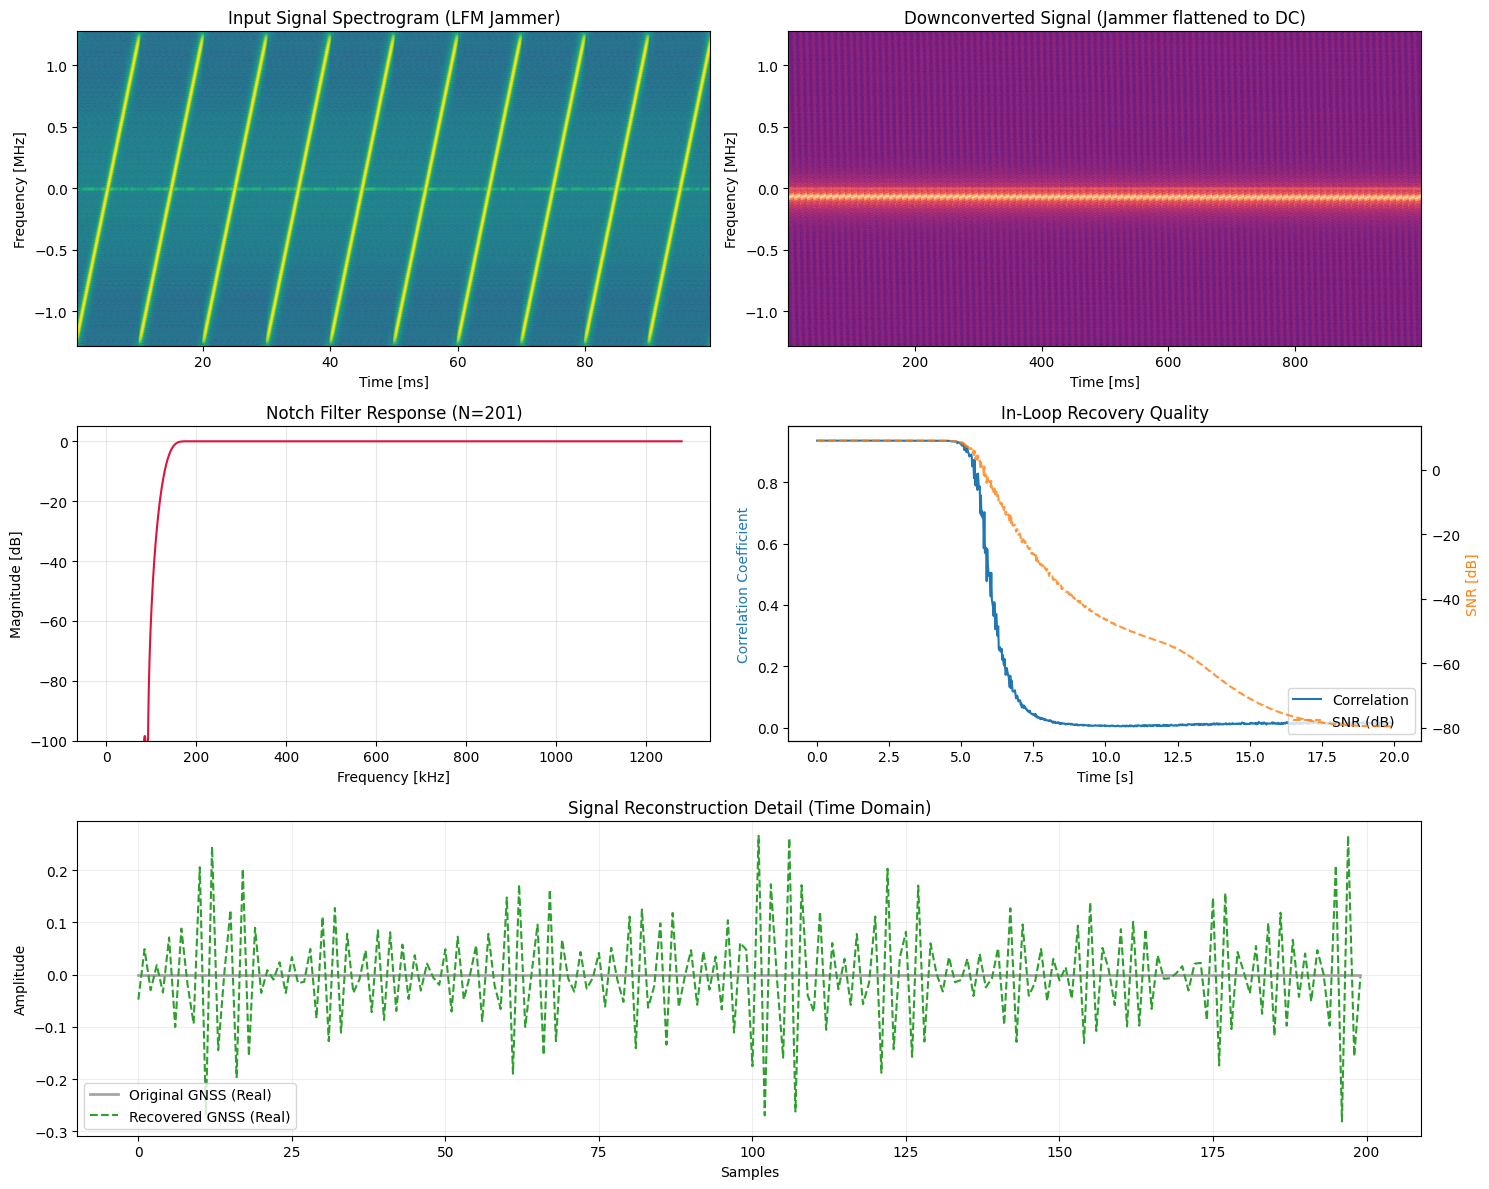

In [4]:
import matplotlib.pyplot as plt
from scipy.signal import freqz

# --- Visualization Setup ---
fig = plt.figure(figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Spectrogram of the Input Signal (GNSS + Jammer)
ax1 = plt.subplot(3, 2, 1)
# FIX: Removed 'signal.' prefix and used the directly imported 'spectrogram'
f, t, Sxx = spectrogram(signal[:int(0.1*f_samplerate)], f_samplerate, nperseg=1024, noverlap=819, return_onesided=False)
ax1.pcolormesh(t * 1e3, np.fft.fftshift(f) / 1e6, 10 * np.log10(np.fft.fftshift(Sxx, axes=0) + 1e-15), shading='gouraud', cmap='viridis')
ax1.set_title("Input Signal Spectrogram (LFM Jammer)")
ax1.set_ylabel("Frequency [MHz]")
ax1.set_xlabel("Time [ms]")

# 2. Spectrogram of the Downconverted Signal
ax2 = plt.subplot(3, 2, 2)
# FIX: Removed 'signal.' prefix here as well
f_dc, t_dc, Sxx_dc = spectrogram(diag_downconverted[int(7*f_samplerate) : int(8*f_samplerate)], f_samplerate, nperseg=1024, noverlap=819, return_onesided=False)
ax2.pcolormesh(t_dc * 1e3, np.fft.fftshift(f_dc) / 1e6, 10 * np.log10(np.fft.fftshift(Sxx_dc, axes=0) + 1e-15), shading='gouraud', cmap='magma')
ax2.set_title("Downconverted Signal (Jammer flattened to DC)")
ax2.set_ylabel("Frequency [MHz]")
ax2.set_xlabel("Time [ms]")

# 3. Filter Frequency Response
ax3 = plt.subplot(3, 2, 3)
w, h_freq = freqz(h, worN=8000)
ax3.plot((w / np.pi) * (f_samplerate / 2) / 1e3, 20 * np.log10(abs(h_freq) + 1e-12), color='crimson')
ax3.set_title(f"Notch Filter Response (N={N_taps})")
ax3.set_ylabel("Magnitude [dB]")
ax3.set_xlabel("Frequency [kHz]")
ax3.grid(True, alpha=0.3)
ax3.set_ylim([-100, 5])

# 4. Telemetry: Rolling Correlation & SNR
ax4 = plt.subplot(3, 2, 4)
ax4_twin = ax4.twinx()
lns1 = ax4.plot(time_stamps, rolling_corr, label='Correlation', color='tab:blue', linewidth=1.5)
lns2 = ax4_twin.plot(time_stamps, rolling_snr, label='SNR (dB)', color='tab:orange', linestyle='--', alpha=0.8)
ax4.set_title("In-Loop Recovery Quality")
ax4.set_xlabel("Time [s]")
ax4.set_ylabel("Correlation Coefficient", color='tab:blue')
ax4_twin.set_ylabel("SNR [dB]", color='tab:orange')
# Legend handling
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax4.legend(lns, labs, loc='lower right')

# 5. Time Domain Comparison (Zoomed)
ax5 = plt.subplot(3, 1, 3)
zoom_slice = slice(safety_margin + 1000, safety_margin + 1200)
ax5.plot(reference_clean[zoom_slice].real, label='Original GNSS (Real)', alpha=0.7, color='gray', lw=2)
ax5.plot(reference_filtered[zoom_slice].real, label='Recovered GNSS (Real)', linestyle='--', color='tab:green')
ax5.set_title("Signal Reconstruction Detail (Time Domain)")
ax5.set_xlabel("Samples")
ax5.set_ylabel("Amplitude")
ax5.legend()
ax5.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import fftconvolve, spectrogram
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from matplotlib import ticker

# --- Path & Custom Library Setup ---
sys.path.append('../../')
from Code.scripts.adaptive_notch_filter_functions import (
    JammerSignalProcessor,
    GoldCodeGenerator
)

# -------------------------------------------------------------------------
# SIMULATION SETUP
# -------------------------------------------------------------------------
# Timing and Frequency Configuration
f_samplerate    = 2.56e6
sweep_time      = 10e-3
main_lobe_width = 1.253e6
jammer_freqs    = [-main_lobe_width, main_lobe_width]
chirp_rate      = (jammer_freqs[1] - jammer_freqs[0]) / sweep_time
jitter_std      = 1e3
jammer_amp_dB   = 80
taper_ratio     = 0.1

# Vectors
N_samples = int(10.0 * f_samplerate)
t_vec     = np.arange(N_samples) / f_samplerate

# Generate the Signal of Interest (GNSS with PRN = 27)
gen = GoldCodeGenerator(PRN=27, samp_rate=f_samplerate, vectorLength=N_samples)
signal_of_interest = gen.process()  

# Generate LFM Jamming signal (Chirp Jammer)
jammer = GoldCodeGenerator.create_linear_FM_signal(
    jammer_freqs, 
    t_vec, 
    f_samplerate, 
    amplitude=10**(jammer_amp_dB/20), 
    chirp_rate  = chirp_rate, 
    jitter_std  = jitter_std, 
    taper_ratio = taper_ratio
)

# Observe the combined signal
signal = signal_of_interest + jammer

print(f"Jammer parameters: \nChirp Rate: {chirp_rate:.2f} Hz/s\nFrequency Range: {jammer_freqs[0]:.2f} to {jammer_freqs[1]:.2f} Hz")

# -------------------------------------------------------------------------
# 1. CHUNKING AND PARAMETERIZATION
# -------------------------------------------------------------------------
acquisition_chunk_size = int(0.5 * f_samplerate) 
start_idx = 26453 # Selected window offset
taper_sec = 0.0002 # 200µs Tukey windowing

# Extract chunk for analysis
acquisition_chunk = signal[start_idx : start_idx + acquisition_chunk_size]

# Parameterization (Includes Sub-Bin Peak Detection & Drift Refinement)
params = JammerSignalProcessor.estimate_jammer_physics(
    acquisition_chunk, 
    f_samplerate, 
    start_idx, 
    taper_sec, 
    spectrogram_nperseg=1024, 
    spectrogram_overlap=819
)

# -------------------------------------------------------------------------
# 2. DESIGNING AN ADAPTIVE NOTCH FILTER
# -------------------------------------------------------------------------
N_taps, notch_width, transition_width_Hz = JammerSignalProcessor.calculate_filter_parameters(
    params.chirp_rate, 
    f_samplerate,
    params.bandwidth,
    notch_width_percentage=0.2,
    transition_width_multiplier=0.1,
    max_phase=1.17
)

attenuation_dB = 81

h = JammerSignalProcessor.dc_firwin_filter(N_taps, f_samplerate, notch_width, attenuation_dB, transition_width_Hz)
group_delay = (N_taps - 1) // 2

print(f"Filter Ready: {N_taps} Taps | Group Delay: {group_delay} samples")

# -------------------------------------------------------------------------
# 3. PROCESSING: Continuous Overlap-Add (OLA) Loop
# -------------------------------------------------------------------------

chunk_size = int(0.02 * f_samplerate) # 20ms processing blocks
tail_length   = N_taps - 1
output_signal = np.zeros(N_samples + tail_length, dtype=complex)

# Telemetry
diag_downconverted = np.zeros(N_samples, dtype=complex)
rolling_corr, rolling_snr, time_stamps = [], [], []

# --- Tracking Initializations ---
current_phase_offset = 0.0
tracking_interval_samples = int(1.0 * f_samplerate) # Track drift every 1.0 seconds

for i_start in tqdm(range(0, N_samples, chunk_size)):
    i_end = min(i_start + chunk_size, N_samples)
    current_length = i_end - i_start
    if current_length == 0: break
    
    full_convolution_length = current_length + tail_length
    signal_chunk  = signal[i_start : i_end]

    # =====================================================================
    # THE BLOCK TRACKER (Executes once per second to kill drift)
    # =====================================================================
    if i_start > 0 and i_start % tracking_interval_samples == 0:
        
        # 1. Grab 1-second telemetry block
        recent_residual = diag_downconverted[i_start - tracking_interval_samples : i_start]
        
        # 2. Inline Sub-Bin Spectrogram to measure drift slant
        f_axis, t_axis, Sxx = spectrogram(recent_residual, fs=f_samplerate, nperseg=1024, noverlap=800, return_onesided=False)
        max_indices = np.argmax(Sxx, axis=0)
        f_res = f_axis[max_indices]
        
        bin_width = f_axis[1] - f_axis[0]
        for idx, k in enumerate(max_indices):
            if 0 < k < len(f_axis) - 1:
                left, center, right = Sxx[k-1, idx], Sxx[k, idx], Sxx[k+1, idx]
                denom = left - 2*center + right
                if denom != 0:
                    f_res[idx] += (0.5 * (left - right) / denom) * bin_width
                    
        f_res_unwrapped = np.unwrap(f_res * 2 * np.pi / f_samplerate) * f_samplerate / (2 * np.pi)
        delta_k, delta_f_start, _, _, _ = stats.linregress(t_axis, f_res_unwrapped)
        
        # 3. Calculate Phase Continuity Hand-off
        t_boundary = i_start / f_samplerate
        t_aligned = t_boundary - params.t_sync
        
        cycle_number = int(np.floor(t_aligned / params.sweep_period))
        t_in_sweep = t_aligned - (cycle_number * params.sweep_period)
        
        # Where the old LO phase is resting right now
        old_phase = (params.f_start * t_in_sweep) + (0.5 * params.chirp_rate * t_in_sweep**2) + \
                    (cycle_number * (params.f_start * params.sweep_period + 0.5 * params.chirp_rate * params.sweep_period**2)) + \
                    current_phase_offset
                    
        # 4. Update the Parameters safely
        params.chirp_rate += delta_k
        params.f_start += delta_f_start
        params.sweep_period = params.bandwidth / abs(params.chirp_rate)
        
        # 5. Calculate where the NEW LO would be, and find the difference
        new_cycle_number = int(np.floor(t_aligned / params.sweep_period))
        new_t_in_sweep = t_aligned - (new_cycle_number * params.sweep_period)
        
        new_phase_raw = (params.f_start * new_t_in_sweep) + (0.5 * params.chirp_rate * new_t_in_sweep**2) + \
                        (new_cycle_number * (params.f_start * params.sweep_period + 0.5 * params.chirp_rate * params.sweep_period**2))
        
        # Save the difference so we can permanently bridge the gap
        current_phase_offset = old_phase - new_phase_raw
    # =====================================================================

    # --- Downconversion LO ---
    t_local = (i_start + np.arange(current_length)) / f_samplerate
    LO_down, _ = JammerSignalProcessor.LO_calculator(   
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_local, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # --- Upconversion LO with Group-Delay Compensation ---
    t_up = (i_start - group_delay + np.arange(full_convolution_length)) / f_samplerate
    _, LO_up = JammerSignalProcessor.LO_calculator(
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_up, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # Apply Block-Tracking Phase Continuity Offset directly to the LO arrays
    phase_correction = np.exp(-1j * 2 * np.pi * current_phase_offset)
    LO_down *= phase_correction
    LO_up *= np.conj(phase_correction)

    # Core DSP Pipeline
    signal_downconverted = signal_chunk * LO_down

    # Filter (Expanding to Full length to capture the ringing tail)
    signal_filtered = fftconvolve(signal_downconverted, h, mode = "full")
    processed_block = signal_filtered * LO_up

    # Overlap-Add: Tail from current chunk sums with the start of the next
    output_signal[i_start : i_start + full_convolution_length] += processed_block
    
    # Diagnostics
    diag_downconverted[i_start:i_end] = signal_downconverted # Capture for spectrogram

    # In-Loop Telemetry (Verify coherence as we go)
    if i_start > 0:
        t_histogram_start = i_start - chunk_size
        clean_slice       = signal_of_interest[t_histogram_start : i_start]
        recovered_slice   = output_signal[t_histogram_start + group_delay : i_start + group_delay]
        
        correlation = JammerSignalProcessor.analyze_correlation(clean_slice, recovered_slice)
        snr  = 10 * np.log10(np.var(clean_slice) / np.var(recovered_slice - clean_slice))
        
        rolling_corr.append(correlation)
        rolling_snr.append(snr)
        time_stamps.append(t_histogram_start / f_samplerate)

# -------------------------------------------------------------------------
# 5. VALIDATION: Final Signal Reconstruction
# -------------------------------------------------------------------------
# Align recovered signal by removing the filter's physical delay
recovered_signal = output_signal[group_delay : N_samples + group_delay]

# Discard edges to avoid filter transient artifacts
safety_margin = N_taps * 2
reference_clean = signal_of_interest[safety_margin : N_samples - safety_margin]
reference_filtered  = recovered_signal[safety_margin : N_samples - safety_margin]

max_correlation = JammerSignalProcessor.analyze_correlation(reference_clean, reference_filtered)

print("\n" + "=" * 50)
print(f"Final Global Correlation: {max_correlation:.4f}")
print("=" * 50)

Jammer parameters: 
Chirp Rate: 250600000.00 Hz/s
Frequency Range: -1253000.00 to 1253000.00 Hz


NameError: name 'phase_offset' is not defined